In [81]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [82]:
ssplist = ["126","245","370","585"]
# ssplist = ["245","370","585"]

In [83]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
# historical_era = [1960,2000]
experiment_era = [1950,2100]
baselineera = [1900,1950]
# tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [84]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [85]:
seed = 42

np.random.seed(seed)

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

baseline for gmt is 60 90
experiment era in the historical is 50 117
baseline for temp records is 0 50
indices of future period are 104 -2
working on 126
working on 245
working on 370
working on 585


In [ ]:
# plt.subplot(1,1,1)
allpred = []

for iseed, seed in enumerate(seedlist):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)
    outputtestclass = np.argmax(outputtest.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt
    # nullval,nulltest = AllData.calculate_nulls(trainvaltest)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True,map_location=torch.device('cpu')) )
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)
        predtest = cnn(inputtest, inputtestGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())

    predtestclass = torch.argmax(predtest, dim=1).numpy()

    acc = np.mean(predvalclass == outputvalclass)
    acctest = np.mean(predtestclass == outputtestclass)
    # gmtacc = np.mean(nullval == outputvalclass)

    # gmttestacc = np.mean(nulltest == outputtestclass)

    print("Seed ", str(seed), "val imbalance: ", str(1-np.mean(outputvalclass)))

    print("Seed ", str(seed), " val accuracy: ", str(acc))
    # print("Seed ", str(seed), " gmt val accuracy: ", str(gmtacc))

    print("Seed ", str(seed), "test imbalance: ", str(1-np.mean(outputtestclass)))
    print("Seed ", str(seed), " test accuracy: ", str(acctest))
    # print("Seed ", str(seed), " gmt test accuracy: ", str(gmttestacc))

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # predseed = allpred[iseed]
    # predseed = np.argmax(predseed, axis=1)
    # predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    # predseedmean = np.mean(predseed, axis=0)
    # plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

# plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
# plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

# gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
# print("GMT only val accuracy: ", str(gmtonlyacc))

# plt.xlim(2000,2040)


baseline for gmt is 60 90
experiment era in the historical is 50 117
baseline for temp records is 0 50
indices of future period are 104 -2
working on 126
working on 245
working on 370
working on 585
Seed  62469869 val imbalance:  0.19300337904989068
Seed  62469869  val accuracy:  0.8069966209501093
Seed  62469869 test imbalance:  0.15805340223944875
Seed  62469869  test accuracy:  0.8419465977605513
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
baseline for gmt is 60 90
experiment era in the historical is 50 117
baseline for temp records is 0 50
indices of future period are 104 -2
working on 126
working on 245
working on 370
working on 585
Seed  71856281 val imbalance:  0.1763068972371298
Seed  71856281  val accuracy:  0.7903001391373484
Seed  71856281 test imbalance:  0.15805340223944875
Seed  71856281  test accuracy:  0.8135228251507322
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
baseline for gmt is 60 90
experiment era in the historical is 50 117
baseline for temp records is

In [87]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

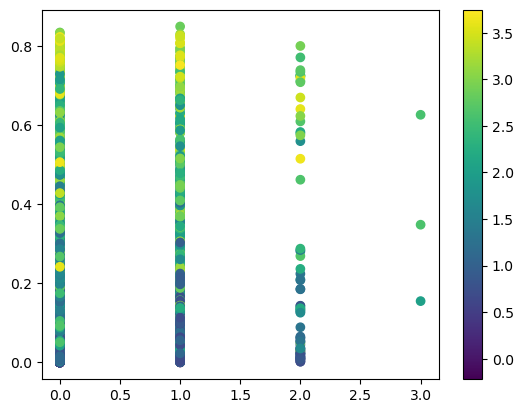

In [103]:
plt.scatter(allsummer,allpred[-1][:,1],c=inputvalGMT.numpy())
plt.colorbar()
# plt.vlines(np.mean(AllData.onesigmas),0,1,color='xkcd:grey',linestyle='dashed')

(array([2528.,  652.,  379.,  296.,  193.,  156.,  130.,   99.,  130.,
         468.]),
 array([8.01221631e-06, 6.47469163e-02, 1.29485816e-01, 1.94224715e-01,
        2.58963615e-01, 3.23702514e-01, 3.88441443e-01, 4.53180343e-01,
        5.17919242e-01, 5.82658112e-01, 6.47397041e-01]),
 <BarContainer object of 10 artists>)

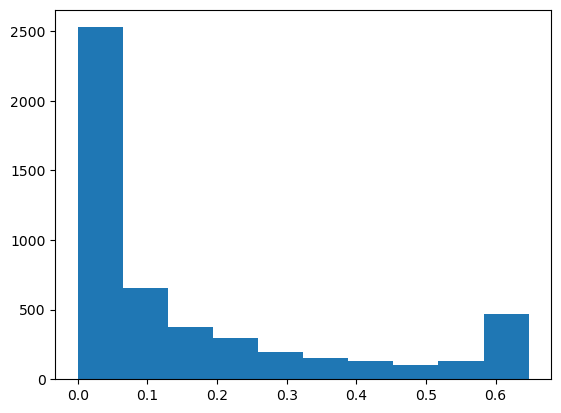

In [100]:
plt.hist(allpred[7][:,1])

In [ ]:
AllData.onesigmas.shape

(50,)

In [ ]:
AllData.truesummer[2].shape

(50, 67)

In [ ]:
allpred[0][:,1].shape

(4199,)

In [ ]:
confusion_mat = np.empty((2,2))
confusion_mat_gmt = np.empty((2,2))

for i in range(2):
    for j in range(2):

        confusion_mat[i,j] = np.mean(1*((predvalclass==i) & (outputvalclass==j)))
        confusion_mat_gmt[i,j] = np.mean(1*((nullval==i) & (outputvalclass==j)))

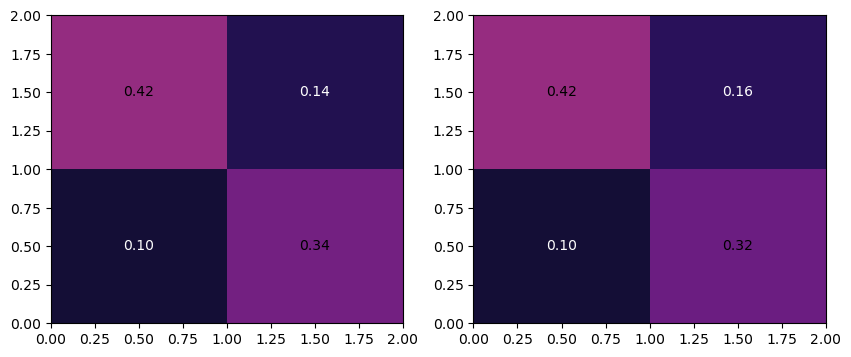

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
im1 = plt.pcolormesh(np.flipud(confusion_mat),vmin=0,vmax=1,cmap='magma')
nrows, ncols = confusion_mat.shape
for i in range(nrows):
    for j in range(ncols):
        val = confusion_mat[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows - i - 0.5
        text_color = 'white' if val < (confusion_mat.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)


plt.subplot(1,2,2)
plt.pcolormesh(np.flipud(confusion_mat_gmt),vmin=0,vmax=1,cmap='magma')
nrows2, ncols2 = confusion_mat_gmt.shape
for i in range(nrows2):
    for j in range(ncols2):
        val = confusion_mat_gmt[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows2 - i - 0.5
        text_color = 'white' if val < (confusion_mat_gmt.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)

In [ ]:
f1score = 2*confusion_mat[1,1]/(2*confusion_mat[1,1] + confusion_mat[1,0] + confusion_mat[0,1])
print(f1score)

f1score_gmt = 2*confusion_mat_gmt[1,1]/(2*confusion_mat_gmt[1,1] + confusion_mat_gmt[1,0] + confusion_mat_gmt[0,1])
print(f1score_gmt)

0.7360208062418725
0.7126925119490175
